## GraphIDS Dataset Analysis

In [11]:
# from google.colab import drive
# drive.mount('/gdrive')
# %cd /gdrive/MyDrive/GraphIDS

In [12]:
import igraph as ig
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
from sklearn.cluster import SpectralClustering
from tqdm.notebook import tqdm

In [13]:
dataset = pl.read_csv("data/NF-UNSW-NB15-v3/NF-UNSW-NB15-v3.csv")

# ── Column aliases ────────────────────────────────────────────────────────────
SRC = "IPV4_SRC_ADDR"
DST = "IPV4_DST_ADDR"
LABEL = "Label"
ATTACK = "Attack"
TIME_COL = "FLOW_START_MILLISECONDS"
DELTA_MS = 5_000


# ── Snapshot builder ──────────────────────────────────────────────────────────
def build_snapshot(df: pl.DataFrame) -> nx.DiGraph:
    G = nx.DiGraph()
    G.add_edges_from(
        (s, d, {"Label": l}) for s, d, l in df.select([SRC, DST, LABEL]).iter_rows()
    )
    return G


# ── Detect the gap ────────────────────────────────────────────────────────────
snap_counts = (
    dataset.with_columns(
        (
            ((pl.col(TIME_COL) - dataset[TIME_COL].min()) / DELTA_MS).cast(pl.Int64)
        ).alias("snapshot_id")
    )
    .group_by("snapshot_id")
    .agg(pl.len().alias("flows"))
    .sort("snapshot_id")
)

gaps = (
    snap_counts.with_columns(
        (pl.col("snapshot_id") - pl.col("snapshot_id").shift(1)).alias("gap")
    )
    .filter(pl.col("gap") > 1000)
    .sort("gap", descending=True)
)
print("Large gaps detected:")
print(gaps.head())

split_sid = gaps["snapshot_id"][0]
ts_min_all = dataset[TIME_COL].min()
split_ts = ts_min_all + split_sid * DELTA_MS
print(
    f"\nSplitting at snapshot_id {split_sid} "
    f"(t = {split_sid * DELTA_MS / 1000:.0f}s from start)"
)


# ── Split & re-index each day from 0 ─────────────────────────────────────────
def make_day(df: pl.DataFrame, ts_min: int) -> pl.DataFrame:
    return df.with_columns(
        (((pl.col(TIME_COL) - ts_min) / DELTA_MS).cast(pl.Int64)).alias("snapshot_id")
    )


raw_day1 = dataset.filter(pl.col(TIME_COL) < split_ts)
raw_day2 = dataset.filter(pl.col(TIME_COL) >= split_ts)

ts_min1 = raw_day1[TIME_COL].min()
ts_min2 = raw_day2[TIME_COL].min()

day1 = make_day(raw_day1, ts_min1)
day2 = make_day(raw_day2, ts_min2)


# ── Build snapshot dicts ──────────────────────────────────────────────────────
def build_snapshots(df: pl.DataFrame) -> dict:
    parts = df.partition_by("snapshot_id", as_dict=True)
    return {sid[0]: build_snapshot(sub) for sid, sub in parts.items()}


print("Building day 1 snapshots...")
snapshots1 = build_snapshots(day1)
print("Building day 2 snapshots...")
snapshots2 = build_snapshots(day2)

# ── Aggregate graphs per day ──────────────────────────────────────────────────
G1 = build_snapshot(raw_day1)
G2 = build_snapshot(raw_day2)
G1_und = G1.to_undirected()
G2_und = G2.to_undirected()

# ── Convenience dict — all subsequent cells iterate over this ─────────────────
days = {
    "Day 1": dict(
        df=day1, raw=raw_day1, snaps=snapshots1, G=G1, G_und=G1_und, ts_min=ts_min1
    ),
    "Day 2": dict(
        df=day2, raw=raw_day2, snaps=snapshots2, G=G2, G_und=G2_und, ts_min=ts_min2
    ),
}

for name, d in days.items():
    snap_ids = sorted(d["snaps"].keys())
    print(f"\n{name}:")
    print(f"  Flows     : {len(d['df']):,}")
    print(f"  Snapshots : {len(snap_ids)}")
    print(f"  Duration  : {(snap_ids[-1] - snap_ids[0]) * DELTA_MS / 1000:.0f}s")
    print(f"  Nodes     : {d['G'].number_of_nodes()}")
    print(f"  Edges     : {d['G'].number_of_edges()}")

Large gaps detected:
shape: (1, 3)
┌─────────────┬───────┬────────┐
│ snapshot_id ┆ flows ┆ gap    │
│ ---         ┆ ---   ┆ ---    │
│ i64         ┆ u32   ┆ i64    │
╞═════════════╪═══════╪════════╡
│ 458326      ┆ 17    ┆ 449257 │
└─────────────┴───────┴────────┘

Splitting at snapshot_id 458326 (t = 2291630s from start)
Building day 1 snapshots...
Building day 2 snapshots...

Day 1:
  Flows     : 1,135,352
  Snapshots : 8633
  Duration  : 45345s
  Nodes     : 40
  Edges     : 283

Day 2:
  Flows     : 1,230,072
  Snapshots : 8412
  Duration  : 43555s
  Nodes     : 42
  Edges     : 259



Day 1:
  Total flows : 1,135,352
  Benign      : 1,117,890  (98.5%)
  Attack      : 17,462  (1.5%)
  Elevated snapshots (>2× baseline): 1196 / 8633
shape: (10, 3)
┌────────────────┬─────────┬───────┐
│ Attack         ┆ count   ┆ pct   │
│ ---            ┆ ---     ┆ ---   │
│ str            ┆ u32     ┆ f64   │
╞════════════════╪═════════╪═══════╡
│ Benign         ┆ 1117890 ┆ 98.46 │
│ Fuzzers        ┆ 6046    ┆ 0.53  │
│ Exploits       ┆ 5622    ┆ 0.5   │
│ Generic        ┆ 2405    ┆ 0.21  │
│ Reconnaissance ┆ 2155    ┆ 0.19  │
│ DoS            ┆ 624     ┆ 0.05  │
│ Shellcode      ┆ 280     ┆ 0.02  │
│ Analysis       ┆ 267     ┆ 0.02  │
│ Backdoor       ┆ 43      ┆ 0.0   │
│ Worms          ┆ 20      ┆ 0.0   │
└────────────────┴─────────┴───────┘

Day 2:
  Total flows : 1,230,072
  Benign      : 1,119,841  (91.0%)
  Attack      : 110,231  (9.0%)
  Elevated snapshots (>2× baseline): 388 / 8412
shape: (10, 3)
┌────────────────┬─────────┬───────┐
│ Attack         ┆ count   ┆ pct   │
│ --- 

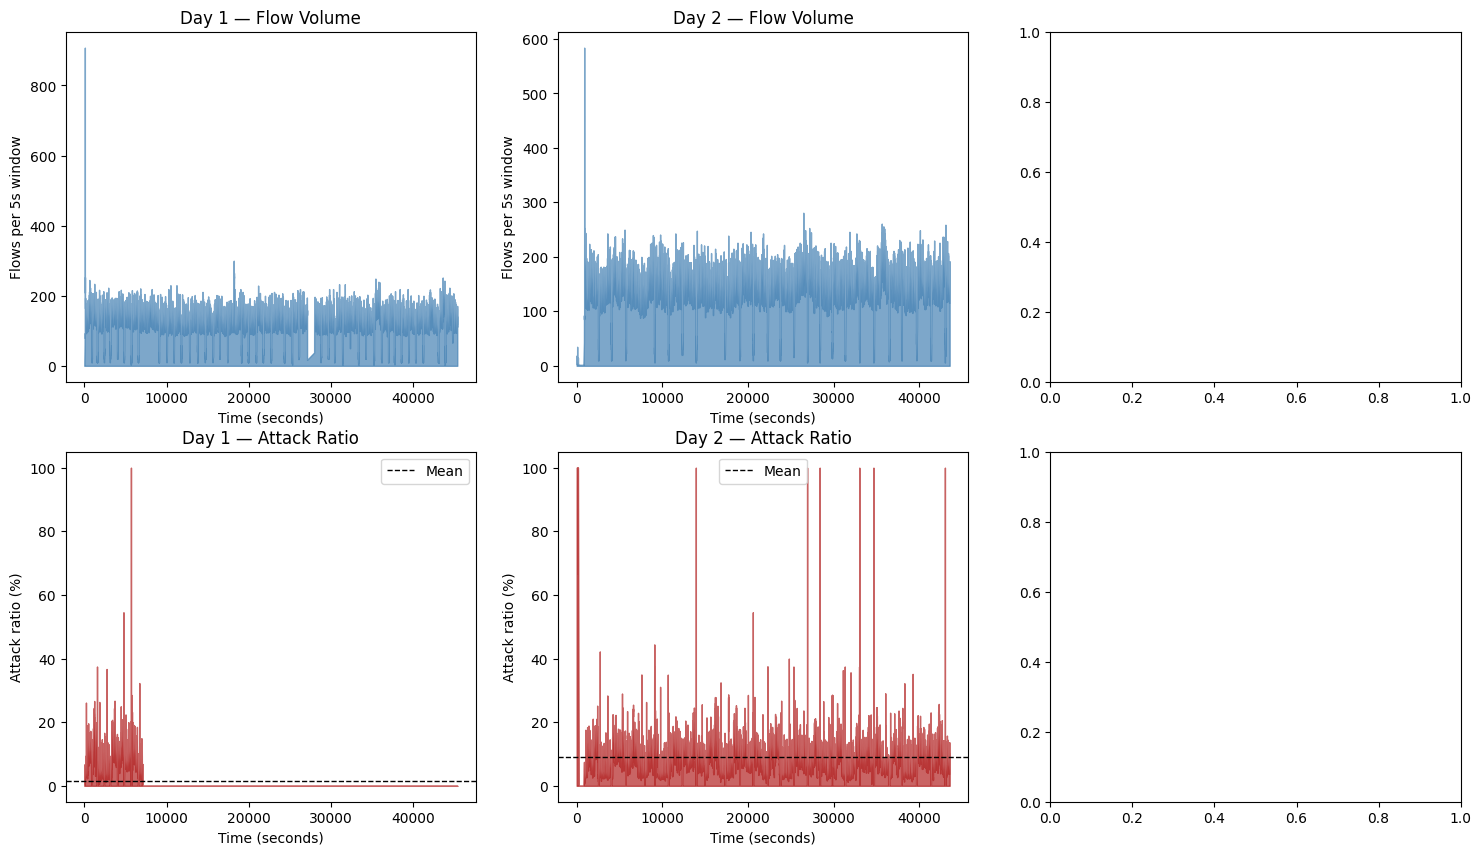

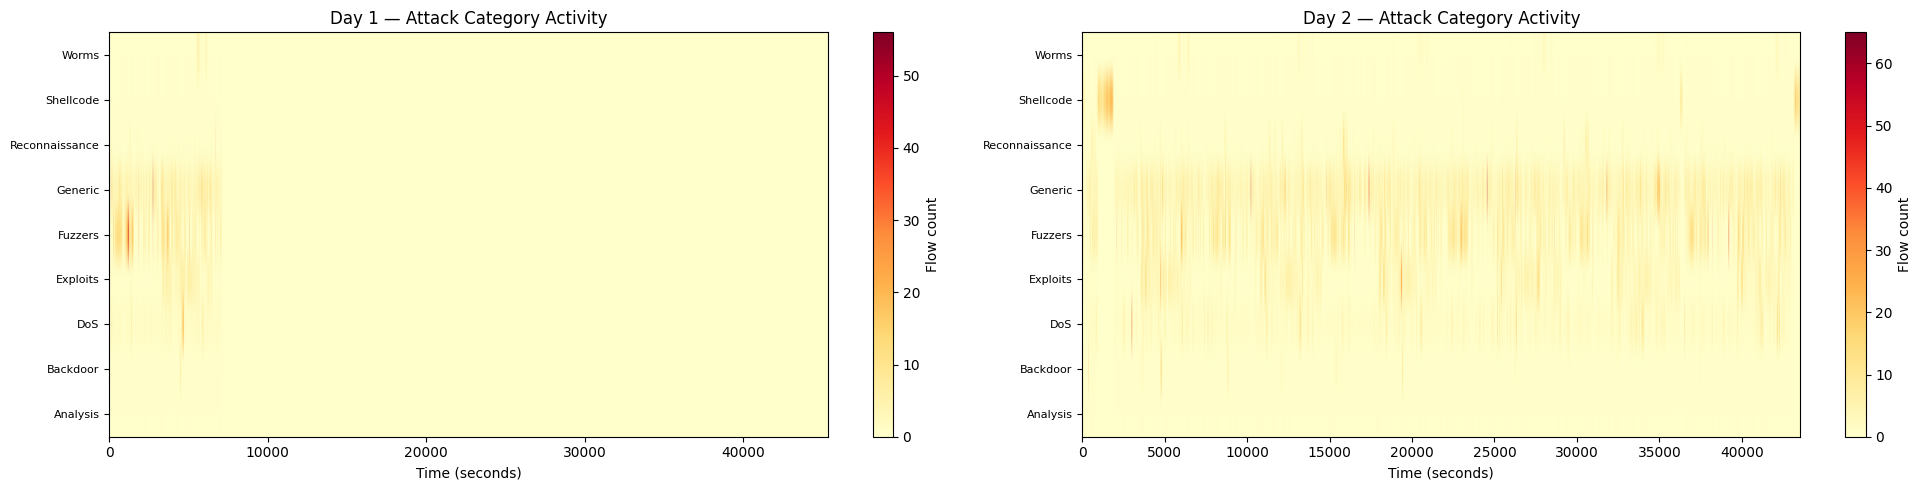

In [14]:
def with_pct(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        (pl.col("count") / pl.col("count").sum() * 100).round(2).alias("pct")
    )


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, d) in enumerate(days.items()):
    df = d["df"]
    snap_stats = (
        df.group_by("snapshot_id")
        .agg([pl.len().alias("flows"), pl.col(LABEL).mean().alias("attack_ratio")])
        .sort("snapshot_id")
    )
    t = snap_stats["snapshot_id"].to_numpy() * DELTA_MS / 1000
    flows = snap_stats["flows"].to_numpy()
    ar = snap_stats["attack_ratio"].to_numpy()

    mean_label = df[LABEL].mean()

    # Flow volume
    axes[0, col].fill_between(t, flows, alpha=0.7, color="steelblue")
    axes[0, col].set_title(f"{name} — Flow Volume")
    axes[0, col].set_ylabel("Flows per 5s window")
    axes[0, col].set_xlabel("Time (seconds)")

    # Attack ratio
    axes[1, col].fill_between(t, ar * 100, alpha=0.7, color="firebrick")
    axes[1, col].axhline(
        mean_label * 100, color="black", linestyle="--", linewidth=1, label="Mean"
    )
    axes[1, col].set_title(f"{name} — Attack Ratio")
    axes[1, col].set_ylabel("Attack ratio (%)")
    axes[1, col].set_xlabel("Time (seconds)")
    axes[1, col].legend()

    # Printed stats — single pass
    total, n_attack = df.select(
        [
            pl.len().alias("total"),
            pl.col(LABEL).sum().alias("n_attack"),
        ]
    ).row(0)
    elevated = snap_stats.filter(pl.col("attack_ratio") > mean_label * 2).height

    print(f"\n{name}:")
    print(f"  Total flows : {total:,}")
    print(
        f"  Benign      : {total - n_attack:,}  "
        f"({(total - n_attack) / total * 100:.1f}%)"
    )
    print(f"  Attack      : {n_attack:,}  ({n_attack / total * 100:.1f}%)")
    print(f"  Elevated snapshots (>2× baseline): {elevated} / {len(snap_stats)}")
    print(with_pct(df[ATTACK].value_counts().sort("count", descending=True)))

# ── Category heatmap — one per day ────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(20, 5))

for ax, (name, d) in zip(axes2, days.items(), strict=False):
    df = d["df"]

    counts = (
        df.filter(pl.col(LABEL) == 1)
        .group_by(["snapshot_id", ATTACK])
        .agg(pl.len().alias("n"))
    )
    snap_ids = sorted(d["snaps"].keys())
    categories = sorted(counts[ATTACK].unique().to_list())

    cat_to_i = {c: i for i, c in enumerate(categories)}
    sid_to_j = {s: j for j, s in enumerate(snap_ids)}

    cat_matrix = np.zeros((len(categories), len(snap_ids)))
    for row in counts.iter_rows(named=True):
        cat_matrix[cat_to_i[row[ATTACK]], sid_to_j[row["snapshot_id"]]] = row["n"]

    t_day = np.array(snap_ids) * DELTA_MS / 1000

    im = ax.imshow(
        cat_matrix,
        aspect="auto",
        cmap="YlOrRd",
        extent=[t_day.min(), t_day.max(), -0.5, len(categories) - 0.5],
    )
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(categories, fontsize=8)
    ax.set_xlabel("Time (seconds)")
    ax.set_title(f"{name} — Attack Category Activity")
    plt.colorbar(im, ax=ax, label="Flow count")

plt.tight_layout()
plt.show()

Day 1 centrality:   0%|          | 0/8633 [00:00<?, ?it/s]

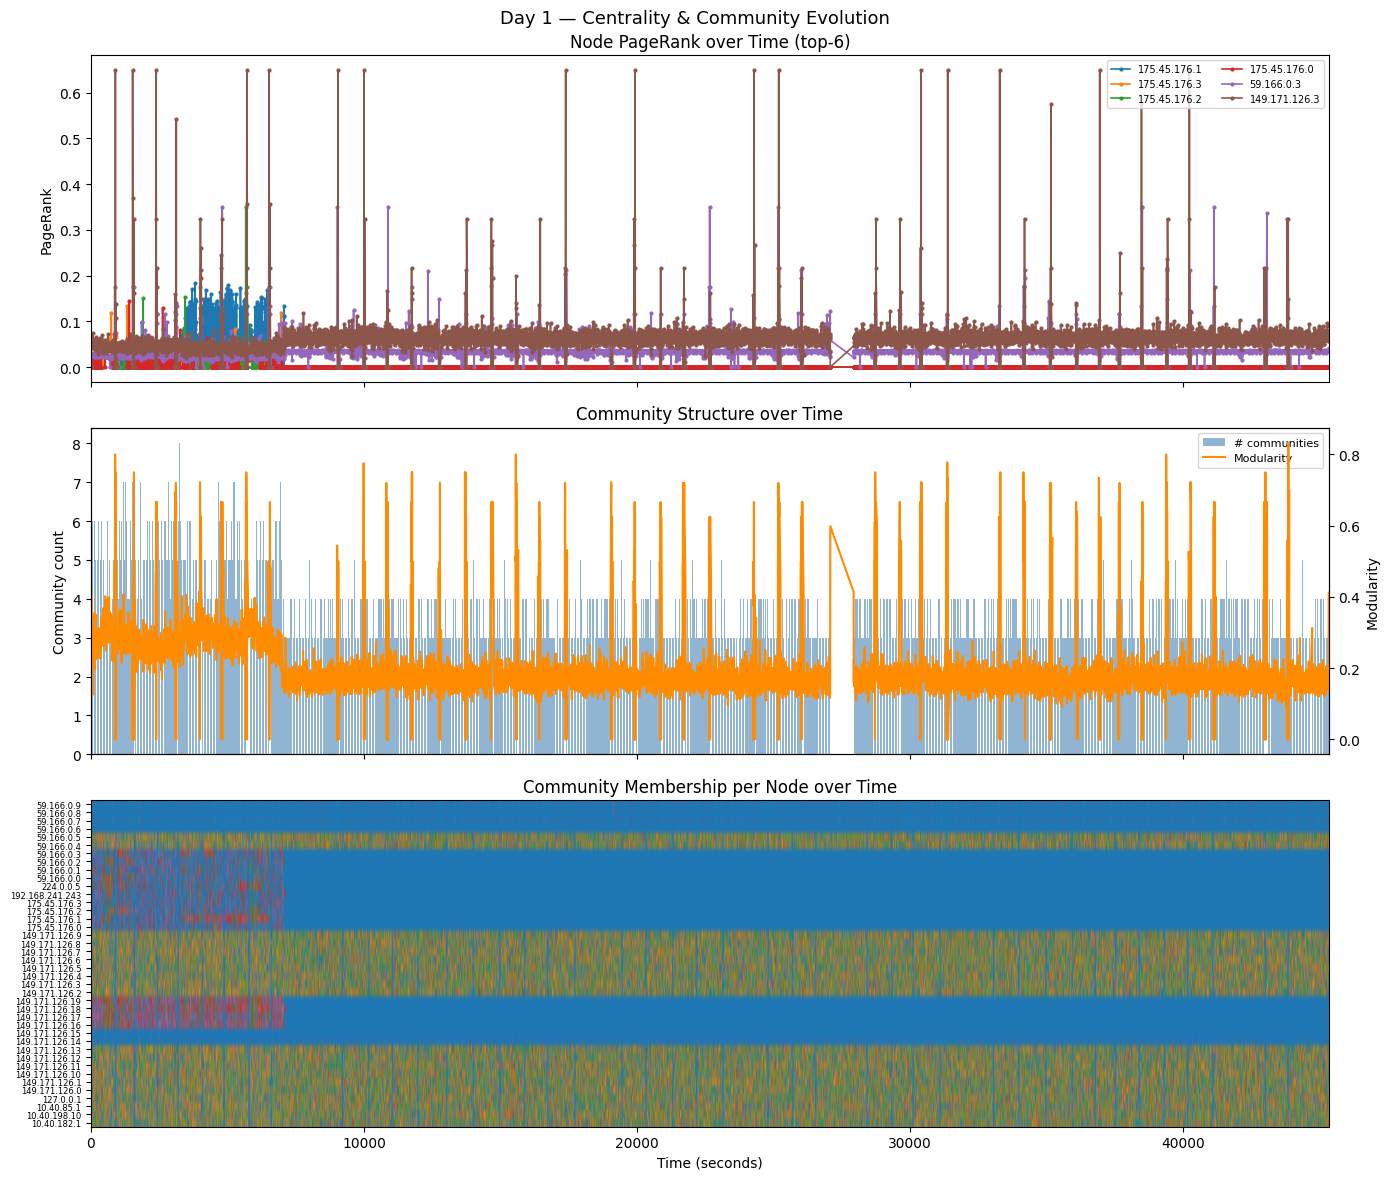


Day 1 — Community summary:
  Mean communities : 3.57
  Mean modularity  : 0.1986

Top-6 nodes by PageRank:
  175.45.176.1           PR=0.05437  in=10  out=10
  175.45.176.3           PR=0.05015  in=10  out=10
  175.45.176.2           PR=0.04145  in=9  out=10
  175.45.176.0           PR=0.04031  in=8  out=10
  59.166.0.3             PR=0.02678  in=10  out=10
  149.171.126.3          PR=0.02678  in=10  out=10


Day 2 centrality:   0%|          | 0/8412 [00:00<?, ?it/s]

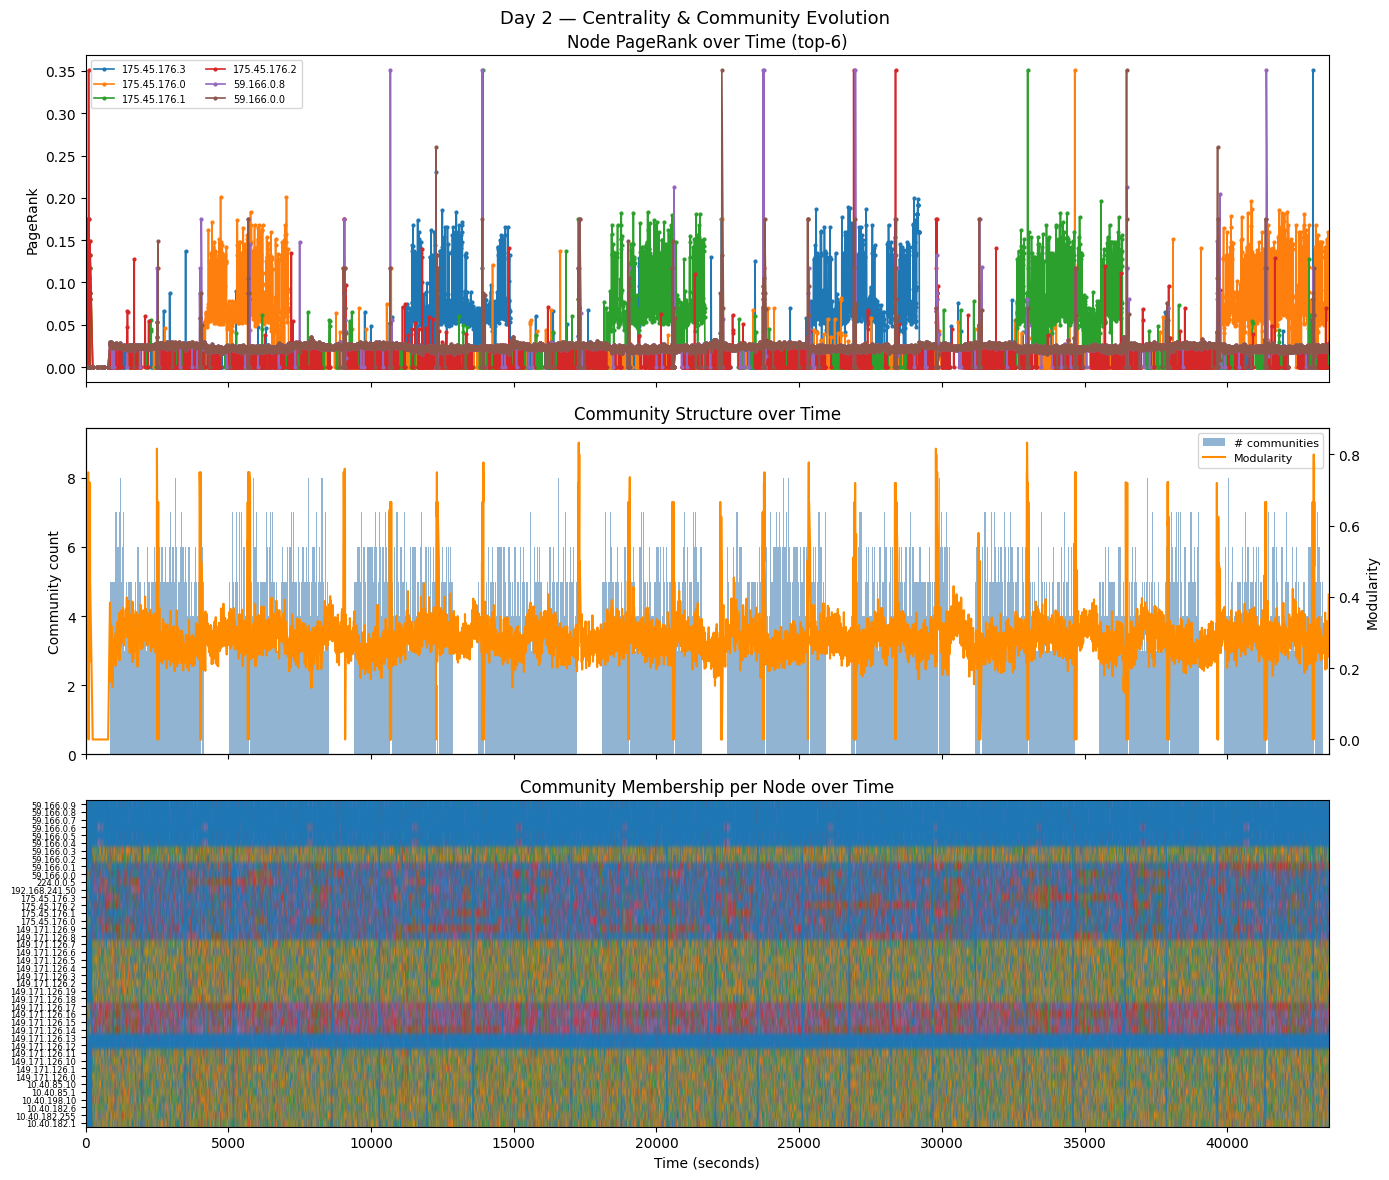


Day 2 — Community summary:
  Mean communities : 4.96
  Mean modularity  : 0.2883

Top-6 nodes by PageRank:
  175.45.176.3           PR=0.04804  in=11  out=10
  175.45.176.0           PR=0.04804  in=11  out=10
  175.45.176.1           PR=0.04804  in=11  out=10
  175.45.176.2           PR=0.04264  in=10  out=10
  59.166.0.8             PR=0.03532  in=9  out=10
  59.166.0.0             PR=0.03275  in=8  out=10


In [15]:
def analyse_centrality(name, d):
    snaps = d["snaps"]
    G = d["G"]
    G_und = d["G_und"]
    snap_ids = sorted(snaps.keys())
    all_nodes = sorted(G.nodes())
    node_idx = {n: i for i, n in enumerate(all_nodes)}
    N = len(all_nodes)
    S = max(snap_ids) + 1

    pr_matrix = np.zeros((S, N))
    comm_matrix = np.full((S, N), -1, dtype=int)
    snap_n_comms = {}
    snap_mod = {}

    for sid in tqdm(snap_ids, desc=f"{name} centrality", leave=True):
        G_t = snaps[sid]
        if G_t.number_of_nodes() == 0:
            continue

        g = ig.Graph.TupleList(G_t.edges(), directed=True)
        pr = g.pagerank(damping=0.85)
        for v, score in zip(g.vs["name"], pr, strict=False):
            if v in node_idx:
                pr_matrix[sid, node_idx[v]] = score

        if g.vcount() > 1:
            g_und = g.as_undirected(mode="collapse")
            comms = g_und.community_multilevel()
            for i, members in enumerate(comms):
                for v_idx in members:
                    name_v = g_und.vs[v_idx]["name"]
                    if name_v in node_idx:
                        comm_matrix[sid, node_idx[name_v]] = i
            snap_n_comms[sid] = len(comms)
            snap_mod[sid] = comms.modularity
        else:
            snap_n_comms[sid] = 1
            snap_mod[sid] = 0.0

    g_full = ig.Graph.TupleList(G.edges(), directed=True)
    agg_pr = dict(zip(g_full.vs["name"], g_full.pagerank(damping=0.85), strict=False))
    top6 = [n for n, _ in sorted(agg_pr.items(), key=lambda x: x[1], reverse=True)[:6]]
    t_axis = np.array(snap_ids) * DELTA_MS / 1000

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(f"{name} — Centrality & Community Evolution", fontsize=13)

    for node in top6:
        idx = node_idx[node]
        axes[0].plot(
            t_axis,
            pr_matrix[snap_ids, idx],
            label=node,
            marker="o",
            markersize=2,
            linewidth=1.2,
        )
    axes[0].set_ylabel("PageRank")
    axes[0].set_title("Node PageRank over Time (top-6)")
    axes[0].legend(fontsize=7, ncol=2)

    comm_counts = [snap_n_comms[s] for s in snap_ids]
    modularity = [snap_mod[s] for s in snap_ids]
    ax2b = axes[1].twinx()
    axes[1].bar(
        t_axis,
        comm_counts,
        width=DELTA_MS / 1000 * 0.8,
        alpha=0.6,
        color="steelblue",
        label="# communities",
    )
    ax2b.plot(t_axis, modularity, color="darkorange", linewidth=1.5, label="Modularity")
    axes[1].set_ylabel("Community count")
    ax2b.set_ylabel("Modularity")
    axes[1].set_title("Community Structure over Time")
    l1, lb1 = axes[1].get_legend_handles_labels()
    l2, lb2 = ax2b.get_legend_handles_labels()
    axes[1].legend(l1 + l2, lb1 + lb2, fontsize=8)

    comm_slice = comm_matrix[snap_ids, :]
    axes[2].imshow(
        comm_slice.T,
        aspect="auto",
        cmap="tab10",
        extent=[t_axis.min(), t_axis.max(), -0.5, N - 0.5],
        vmin=0,
        vmax=9,
    )
    axes[2].set_yticks(range(N))
    axes[2].set_yticklabels(all_nodes, fontsize=6)
    axes[2].set_xlabel("Time (seconds)")
    axes[2].set_title("Community Membership per Node over Time")

    plt.tight_layout()
    plt.show()

    print(f"\n{name} — Community summary:")
    print(f"  Mean communities : {np.mean(comm_counts):.2f}")
    print(f"  Mean modularity  : {np.mean(modularity):.4f}")
    print("\nTop-6 nodes by PageRank:")
    for node in top6:
        print(
            f"  {node:<22} PR={agg_pr[node]:.5f}  "
            f"in={G.in_degree(node)}  out={G.out_degree(node)}"
        )

    return dict(
        pr_matrix=pr_matrix,
        comm_matrix=comm_matrix,
        snap_n_comms=snap_n_comms,
        snap_mod=snap_mod,
        node_idx=node_idx,
        all_nodes=all_nodes,
    )


centrality_results = {}
for name, d in days.items():
    centrality_results[name] = analyse_centrality(name, d)


Day 1


  0%|          | 0/4 [00:00<?, ?it/s]


  Beaconing pairs : 3
  Port sweeps     : 2,337  avg attack ratio: 0.0%
  Bursts          : 269  avg attack ratio: 1.1%
  Propagations    : 26,441

Day 2


  0%|          | 0/4 [00:00<?, ?it/s]


  Beaconing pairs : 7
  Port sweeps     : 2,286  avg attack ratio: 0.0%
  Bursts          : 275  avg attack ratio: 6.2%
  Propagations    : 7,756


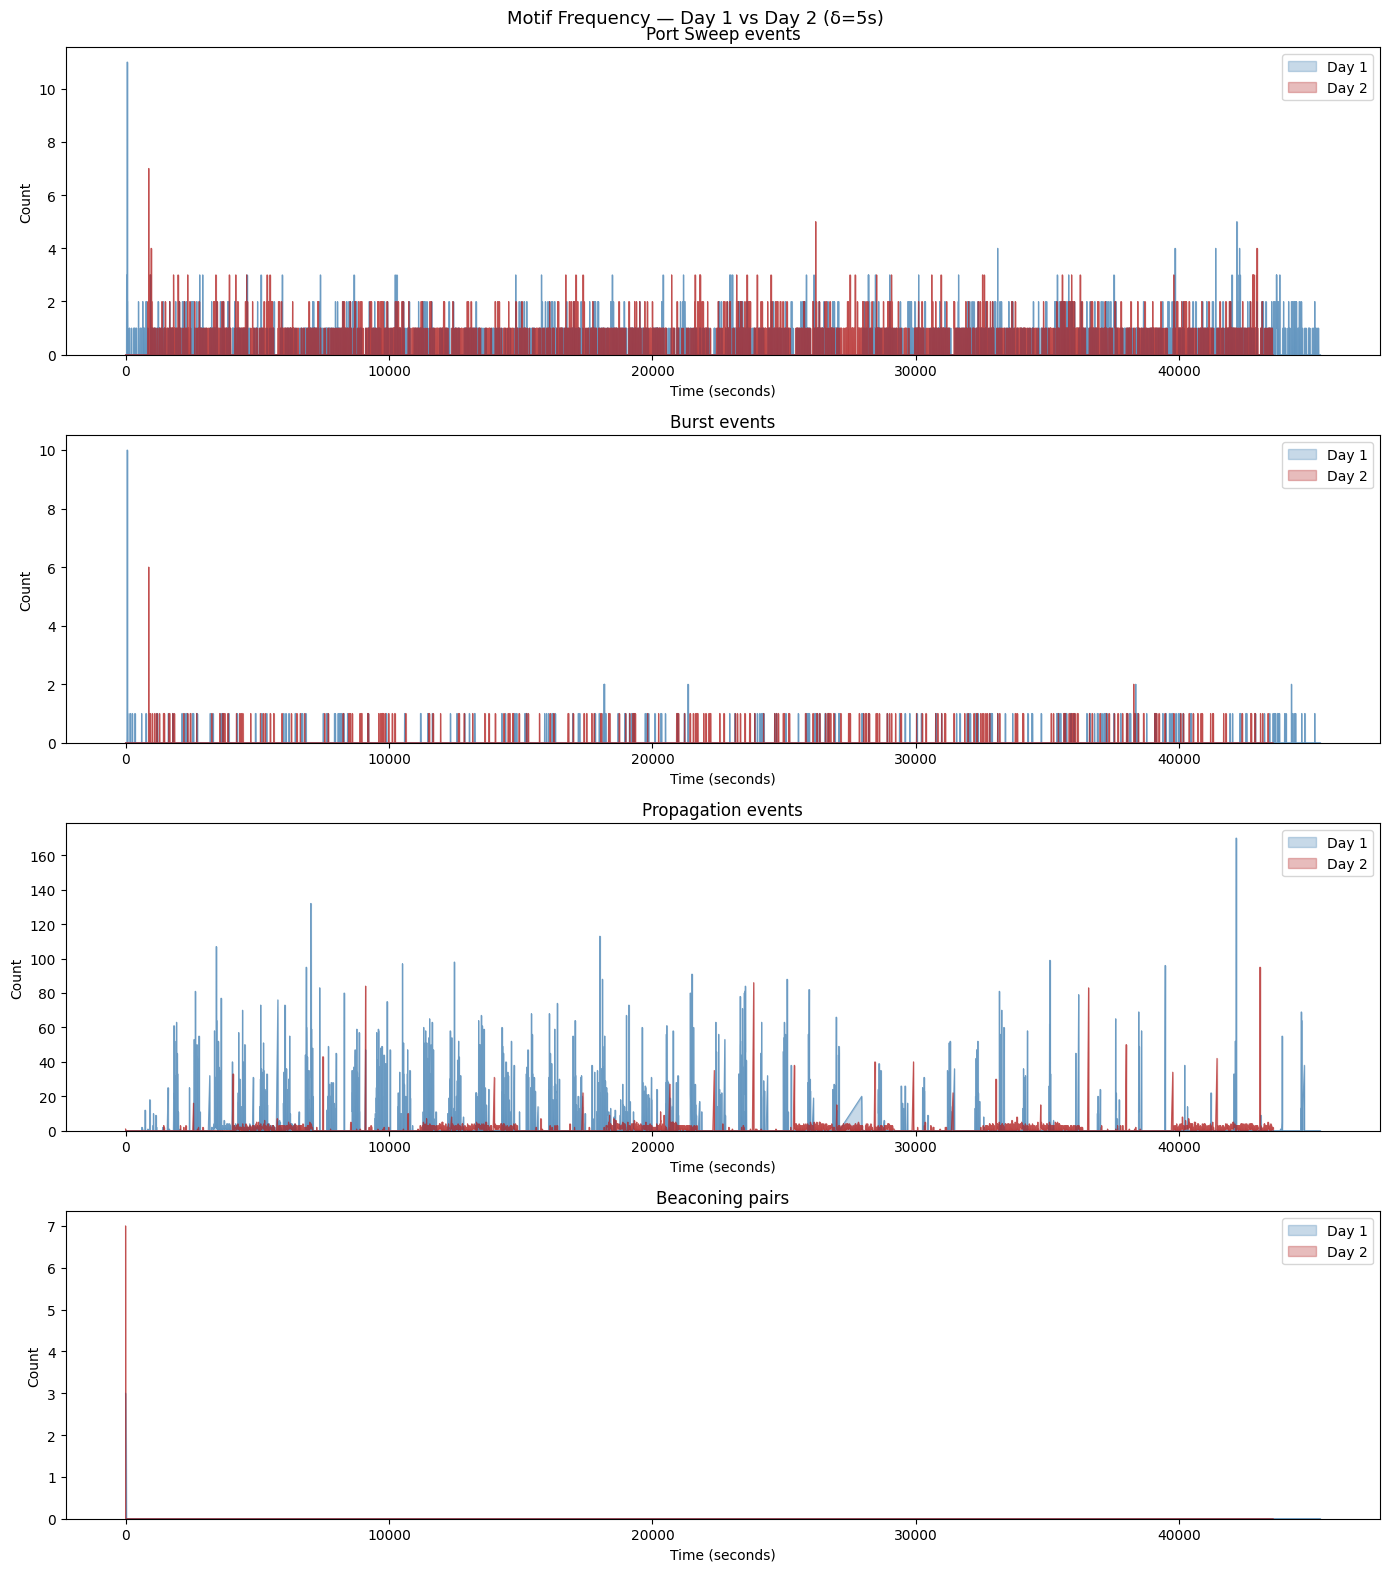

In [16]:
def detect_beaconing(df: pl.DataFrame, cv_threshold=0.4, min_count=3):
    return (
        df.sort(TIME_COL)
        .group_by([SRC, DST])
        .agg(
            [
                pl.col(TIME_COL).diff().drop_nulls().alias("iats"),
                pl.len().alias("count"),
            ]
        )
        .filter(pl.col("count") >= min_count)
        .with_columns(
            [
                pl.col("iats").list.mean().alias("mean"),
                pl.col("iats").list.std().alias("std"),
            ]
        )
        .filter(pl.col("mean") > 0)
        .with_columns((pl.col("std") / pl.col("mean")).alias("cv"))
        .filter(pl.col("cv") < cv_threshold)
        .select([SRC, DST, "count", "cv"])
    )


def detect_port_sweep(df: pl.DataFrame, min_unique_dst=5):
    return (
        df.group_by([SRC, "L4_DST_PORT", "snapshot_id"])
        .agg(
            [
                pl.col(DST).n_unique().alias("unique_dst"),
                pl.col(LABEL).mean().alias("attack_ratio"),
                pl.len().alias("flow_count"),
            ]
        )
        .filter(pl.col("unique_dst") >= min_unique_dst)
    )


def detect_bursts(df: pl.DataFrame, burst_threshold=50):
    return (
        df.group_by([SRC, "snapshot_id"])
        .agg(
            [
                pl.len().alias("count"),
                pl.col(LABEL).mean().alias("attack_ratio"),
            ]
        )
        .filter(pl.col("count") >= burst_threshold)
    )


def detect_propagation(raw_day: pl.DataFrame, delta_ms=DELTA_MS):
    edges = raw_day.select([SRC, DST, "snapshot_id"]).unique()
    nb = raw_day.select([SRC, DST]).unique().rename({DST: "C"})

    ab = edges.rename({SRC: "A", DST: "B"})
    bc = edges.rename({SRC: "B", DST: "C"}).select(["B", "C", "snapshot_id"])

    paths = (
        ab.join(bc, on=["B", "snapshot_id"])
        .filter(pl.col("A") != pl.col("C"))
        .join(nb.rename({SRC: "A"}), on=["A", "C"], how="anti")
        .with_columns((pl.col("snapshot_id") * delta_ms / 1000).alias("time_s"))
        .unique(subset=["A", "B", "C", "snapshot_id"])
    )
    return paths


def run_motifs(name, d):
    print(f"\n{'=' * 50}")
    print(f"{name}")
    print(f"{'=' * 50}")

    df_pl = (
        d["df"]
        .select(
            [SRC, DST, TIME_COL, LABEL, "snapshot_id", "L4_DST_PORT", "L4_SRC_PORT"]
        )
        .sort(TIME_COL)
    )
    snap_ids = sorted(d["snaps"].keys())

    steps = ["Beaconing", "Port Sweep", "Bursts", "Propagation"]
    pbar = tqdm(steps, position=0, leave=True)

    pbar.set_description("Beaconing")
    beacons = detect_beaconing(df_pl)
    print(f"\n  Beaconing pairs : {len(beacons):,}")
    pbar.update(1)

    pbar.set_description("Port Sweep")
    sweeps = detect_port_sweep(df_pl)
    sweep_ar = sweeps["attack_ratio"].mean() if len(sweeps) else 0.0
    print(
        f"  Port sweeps     : {len(sweeps):,}  avg attack ratio: {sweep_ar * 100:.1f}%"
    )
    pbar.update(1)

    pbar.set_description("Bursts")
    bursts = detect_bursts(df_pl)
    burst_ar = bursts["attack_ratio"].mean() if len(bursts) else 0.0
    print(
        f"  Bursts          : {len(bursts):,}  avg attack ratio: {burst_ar * 100:.1f}%"
    )
    pbar.update(1)

    pbar.set_description("Propagation")
    propagations = detect_propagation(d["df"])
    print(f"  Propagations    : {len(propagations):,}")
    pbar.update(1)
    pbar.set_description("Done")
    pbar.close()

    return dict(
        beacons=beacons,
        sweeps=sweeps,
        bursts=bursts,
        propagations=propagations,
        snap_ids=snap_ids,
    )


motif_results = {}
for name, d in days.items():
    motif_results[name] = run_motifs(name, d)


# ── Overlay plot — both days on the same axes ─────────────────────────────────
def _count_by(df: pl.DataFrame, key: str) -> dict:
    if not len(df):
        return {}
    counts = df.group_by(key).agg(pl.len().alias("n"))
    return dict(zip(counts[key].to_list(), counts["n"].to_list(), strict=False))


day_colours = {"Day 1": "steelblue", "Day 2": "firebrick"}

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)
fig.suptitle(f"Motif Frequency — Day 1 vs Day 2 (δ={DELTA_MS // 1000}s)", fontsize=13)

motif_specs = [
    ("Port Sweep events", lambda r: _count_by(r["sweeps"], "snapshot_id")),
    ("Burst events", lambda r: _count_by(r["bursts"], "snapshot_id")),
    ("Propagation events", lambda r: _count_by(r["propagations"], "snapshot_id")),
    (
        "Beaconing pairs",
        lambda r: {r["snap_ids"][0]: len(r["beacons"])} if len(r["beacons"]) else {},
    ),
]

for ax, (title, get_snap_dict) in zip(axes, motif_specs, strict=False):
    for name, results in motif_results.items():
        snap_ids = results["snap_ids"]
        snap_dict = get_snap_dict(results)
        t_axis = np.array(snap_ids) * DELTA_MS / 1000
        y = np.array([snap_dict.get(s, 0) for s in snap_ids])
        colour = day_colours[name]

        ax.fill_between(t_axis, y, alpha=0.3, color=colour, label=f"{name}")
        ax.plot(t_axis, y, color=colour, linewidth=0.8, alpha=0.7)

    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Time (seconds)")
    ax.legend()

plt.tight_layout()
plt.show()

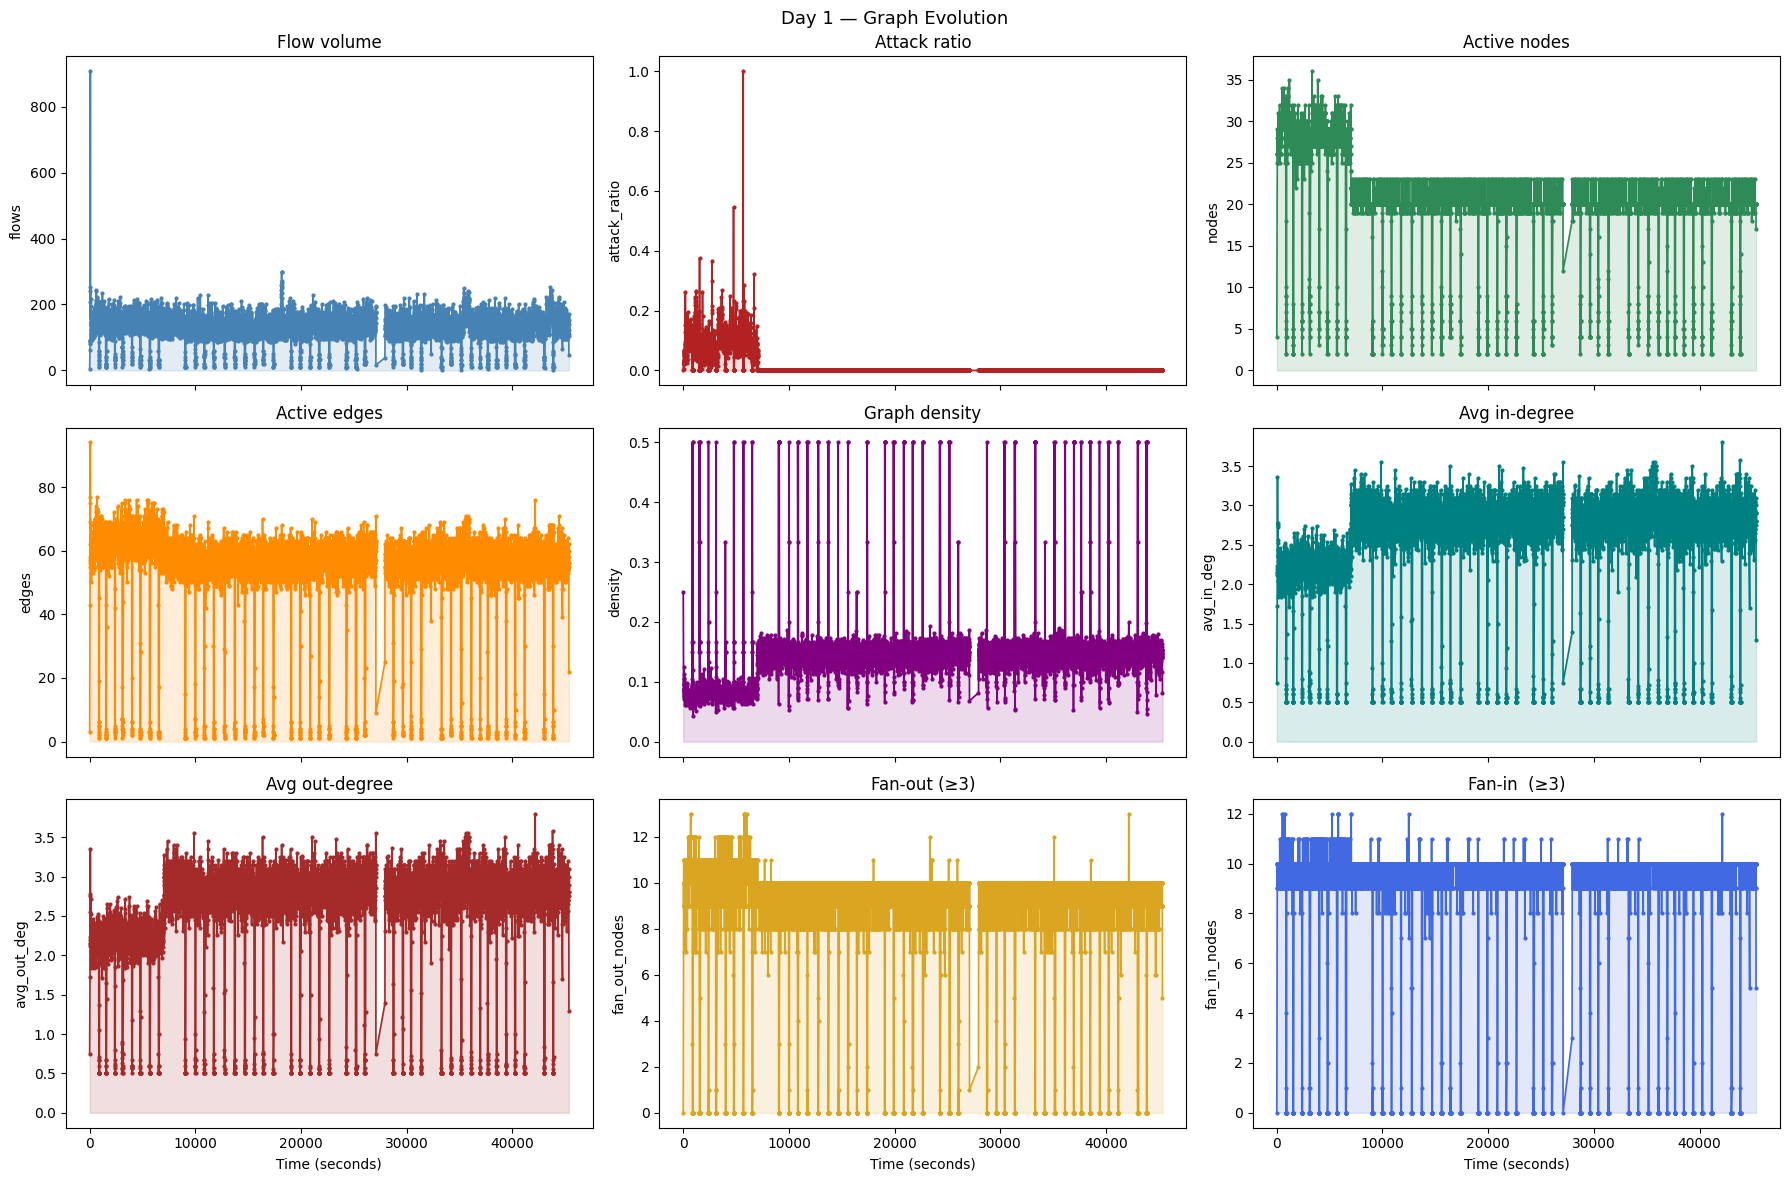


Day 1 — Evolution summary:
shape: (9, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ snapshot_ ┆ flows     ┆ attack_ra ┆ … ┆ avg_out_d ┆ fan_out_n ┆ fan_in_no ┆ time_s   │
│ ---       ┆ id        ┆ ---       ┆ tio       ┆   ┆ eg        ┆ odes      ┆ des       ┆ ---      │
│ str       ┆ ---       ┆ f64       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│           ┆ f64       ┆           ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 8633.0    ┆ 8633.0    ┆ 8633.0    ┆ … ┆ 8633.0    ┆ 8633.0    ┆ 8633.0    ┆ 8633.0   │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 4516.6146 ┆ 131.51303 ┆ 0.014071  

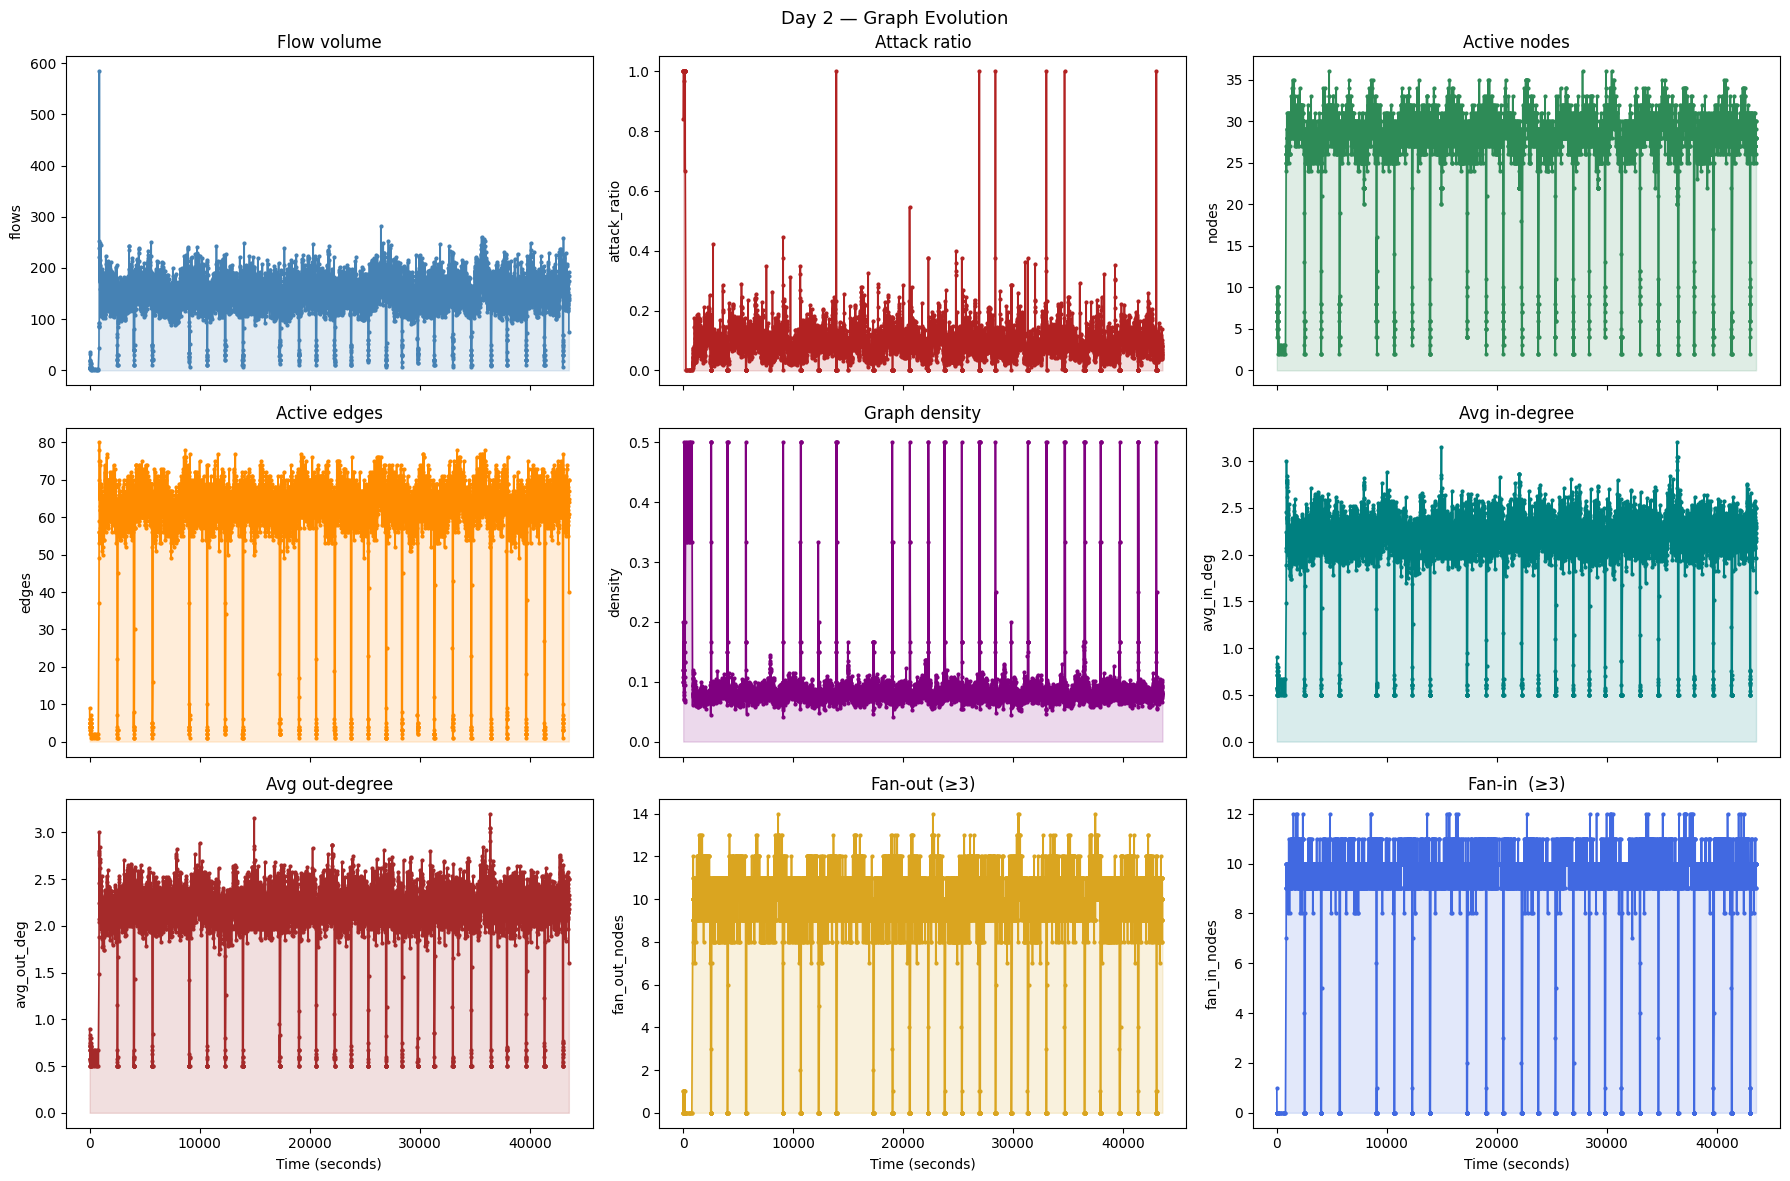


Day 2 — Evolution summary:
shape: (9, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ snapshot_ ┆ flows     ┆ attack_ra ┆ … ┆ avg_out_d ┆ fan_out_n ┆ fan_in_no ┆ time_s   │
│ ---       ┆ id        ┆ ---       ┆ tio       ┆   ┆ eg        ┆ odes      ┆ des       ┆ ---      │
│ str       ┆ ---       ┆ f64       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│           ┆ f64       ┆           ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 8412.0    ┆ 8412.0    ┆ 8412.0    ┆ … ┆ 8412.0    ┆ 8412.0    ┆ 8412.0    ┆ 8412.0   │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 4410.6370 ┆ 146.22824 ┆ 0.092595  

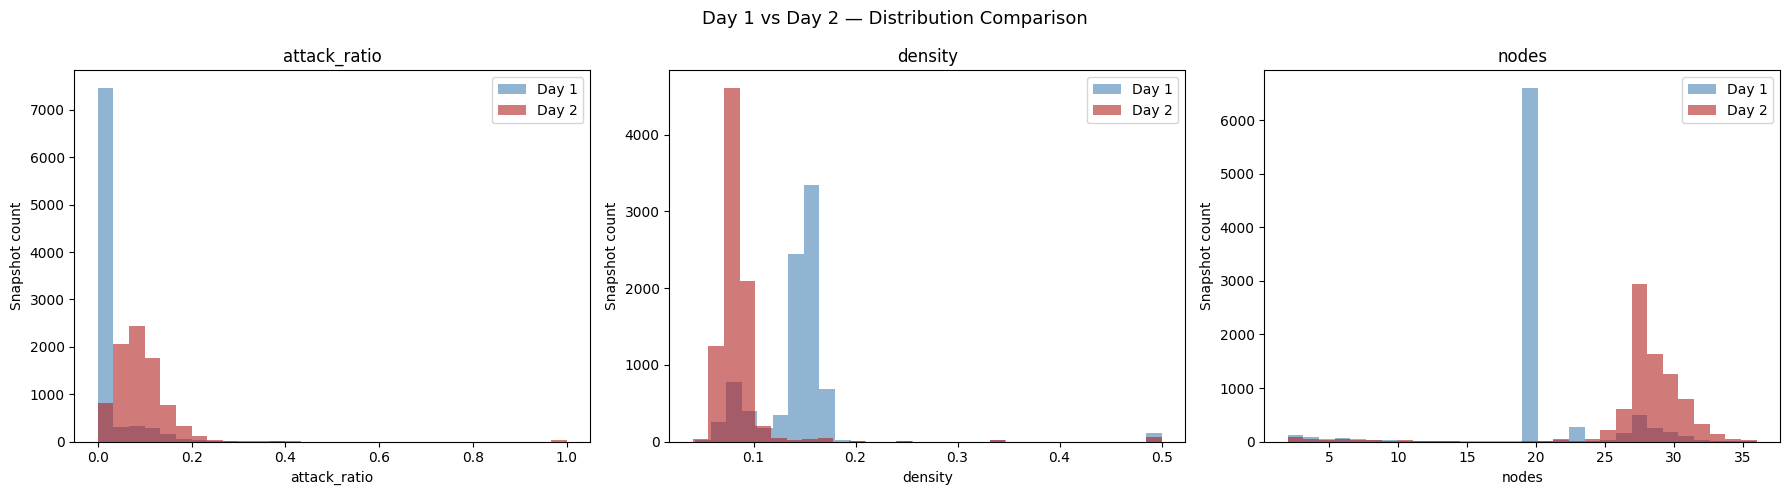

In [17]:
def analyse_evolution(name, d):
    df = d["df"]
    snaps = d["snaps"]
    THRESH = 3

    # Flow-level stats — one pass, no NetworkX
    flow_stats = (
        df.group_by("snapshot_id")
        .agg(
            [
                pl.len().alias("flows"),
                pl.col(LABEL).mean().alias("attack_ratio"),
            ]
        )
        .sort("snapshot_id")
    )

    # Graph-level stats — one pass over snaps, no filtering
    graph_rows = []
    for sid, G_t in snaps.items():
        n = G_t.number_of_nodes()
        e = G_t.number_of_edges()
        out_deg = [d for _, d in G_t.out_degree()]
        in_deg = [d for _, d in G_t.in_degree()]
        graph_rows.append(
            {
                "snapshot_id": sid,
                "nodes": n,
                "edges": e,
                "density": e / (n * (n - 1)) if n > 1 else 0.0,
                "avg_in_deg": float(np.mean(in_deg)) if in_deg else 0.0,
                "avg_out_deg": float(np.mean(out_deg)) if out_deg else 0.0,
                "fan_out_nodes": sum(1 for v in out_deg if v >= THRESH),
                "fan_in_nodes": sum(1 for v in in_deg if v >= THRESH),
            }
        )
    graph_stats = pl.DataFrame(graph_rows)

    met = (
        flow_stats.join(graph_stats, on="snapshot_id")
        .with_columns((pl.col("snapshot_id") * DELTA_MS / 1000).alias("time_s"))
        .sort("snapshot_id")
    )
    t = met["time_s"].to_numpy()

    fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
    fig.suptitle(f"{name} — Graph Evolution", fontsize=13)
    plot_cols = [
        ("flows", "Flow volume", "steelblue"),
        ("attack_ratio", "Attack ratio", "firebrick"),
        ("nodes", "Active nodes", "seagreen"),
        ("edges", "Active edges", "darkorange"),
        ("density", "Graph density", "purple"),
        ("avg_in_deg", "Avg in-degree", "teal"),
        ("avg_out_deg", "Avg out-degree", "brown"),
        ("fan_out_nodes", f"Fan-out (≥{THRESH})", "goldenrod"),
        ("fan_in_nodes", f"Fan-in  (≥{THRESH})", "royalblue"),
    ]
    for ax, (col, title, colour) in zip(axes.flat, plot_cols, strict=False):
        y = met[col].to_numpy()
        ax.plot(t, y, color=colour, linewidth=1.2, marker="o", markersize=2)
        ax.fill_between(t, y, alpha=0.15, color=colour)
        ax.set_title(title)
        ax.set_ylabel(col)
    for ax in axes[-1]:
        ax.set_xlabel("Time (seconds)")
    plt.tight_layout()
    plt.show()

    print(f"\n{name} — Evolution summary:")
    print(met.describe())
    return met


evolution_results = {}
for name, d in days.items():
    evolution_results[name] = analyse_evolution(name, d)

# ── Cross-day comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Day 1 vs Day 2 — Distribution Comparison", fontsize=13)
metrics = ["attack_ratio", "density", "nodes"]
for ax, col in zip(axes, metrics, strict=False):
    for name, colour in zip(days.keys(), ["steelblue", "firebrick"], strict=False):
        ax.hist(
            evolution_results[name][col].to_numpy(),
            bins=30,
            alpha=0.6,
            label=name,
            color=colour,
        )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Snapshot count")
    ax.legend()
plt.tight_layout()
plt.show()

/home/talos-1/miniforge3/envs/env_research/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


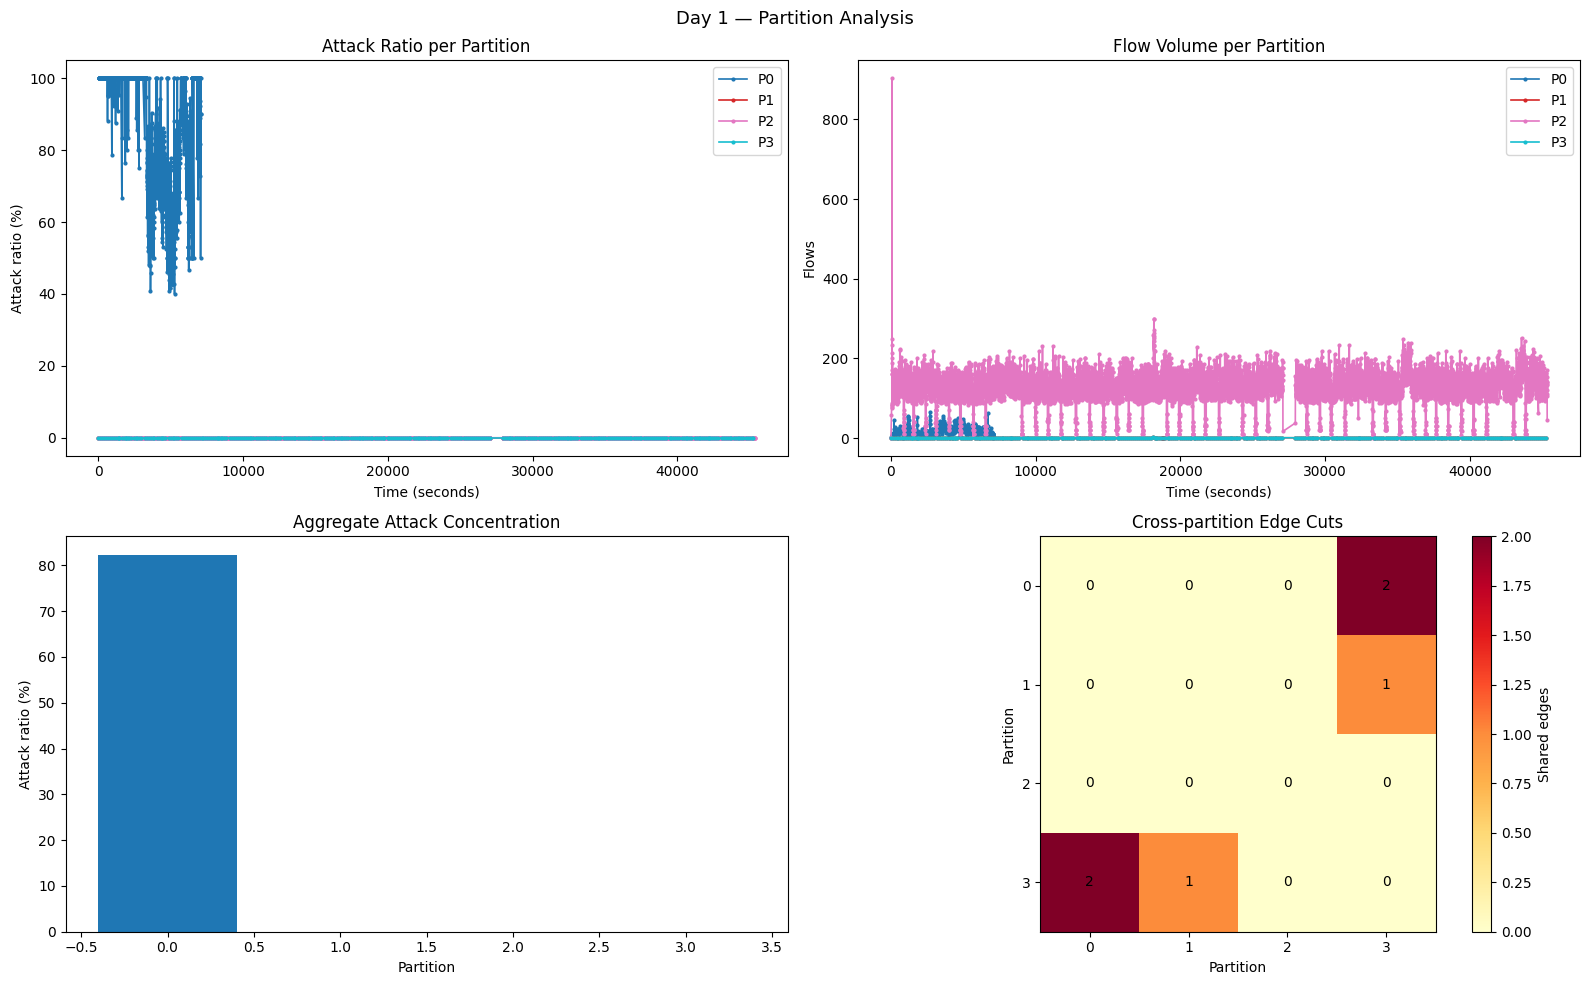


Day 1 — Partition summary:
  Edge cut: 3 / 148 (2.0%)
shape: (4, 3)
┌───────────┬─────────┬──────────────┐
│ partition ┆ flows   ┆ attack_ratio │
│ ---       ┆ ---     ┆ ---          │
│ i64       ┆ u32     ┆ f64          │
╞═══════════╪═════════╪══════════════╡
│ 0         ┆ 21233   ┆ 0.822399     │
│ 1         ┆ 324     ┆ 0.0          │
│ 2         ┆ 1113472 ┆ 0.0          │
│ 3         ┆ 323     ┆ 0.0          │
└───────────┴─────────┴──────────────┘


/home/talos-1/miniforge3/envs/env_research/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


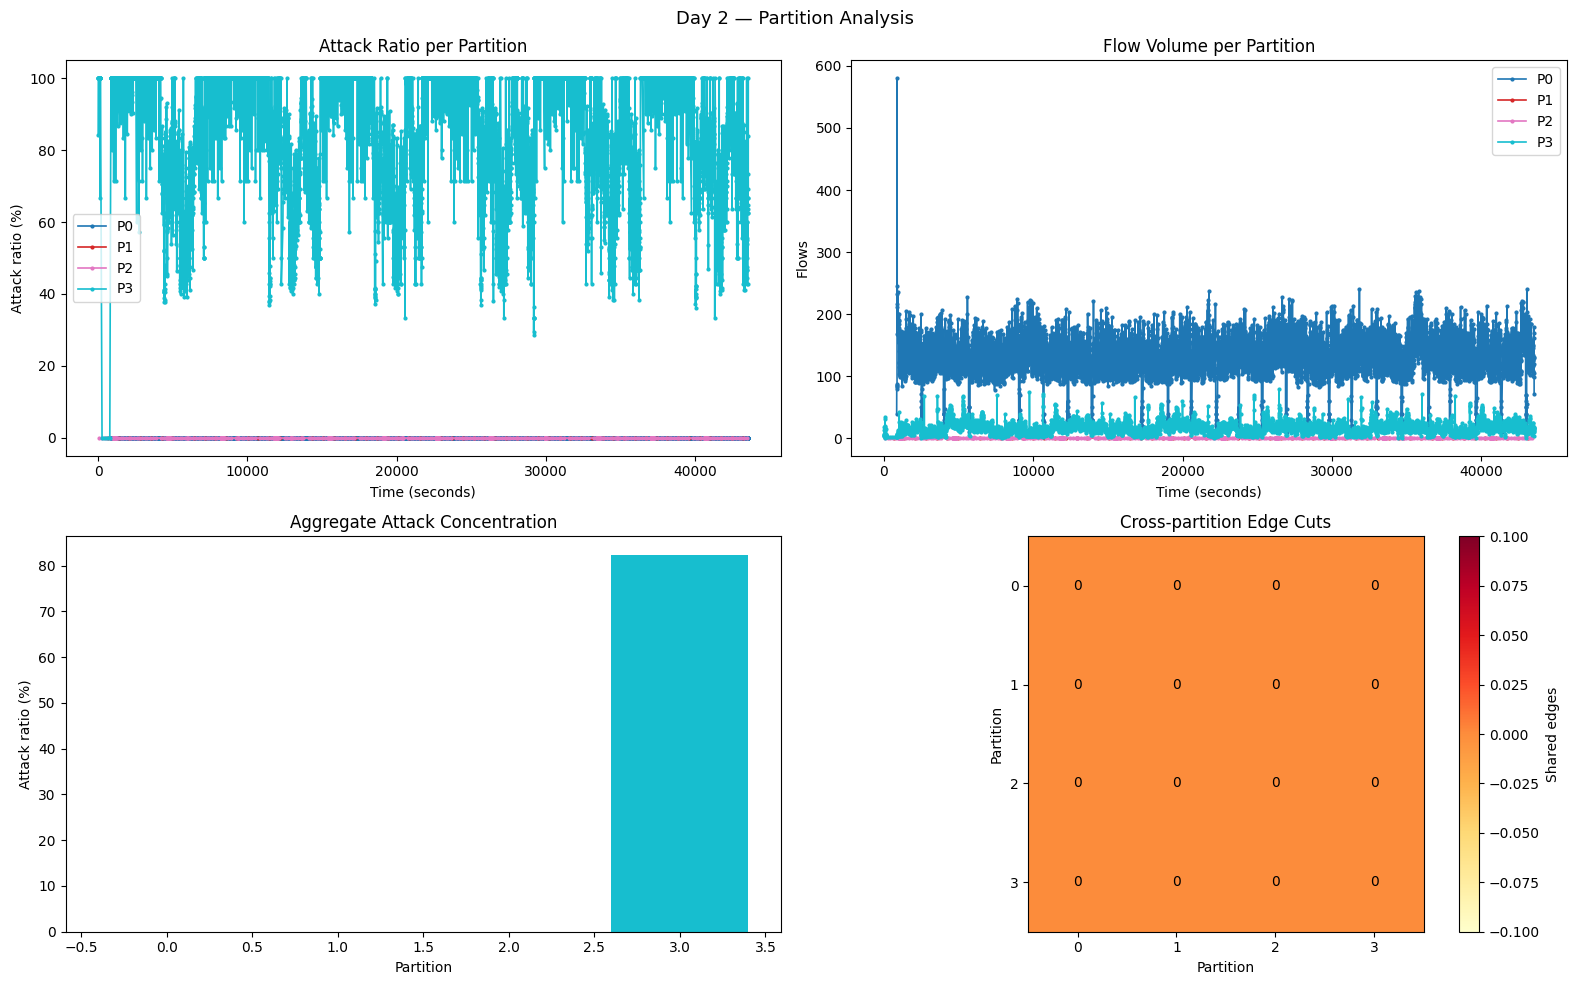


Day 2 — Partition summary:
  Edge cut: 0 / 153 (0.0%)
shape: (4, 3)
┌───────────┬─────────┬──────────────┐
│ partition ┆ flows   ┆ attack_ratio │
│ ---       ┆ ---     ┆ ---          │
│ i64       ┆ u32     ┆ f64          │
╞═══════════╪═════════╪══════════════╡
│ 0         ┆ 1095616 ┆ 0.0          │
│ 1         ┆ 58      ┆ 0.0          │
│ 2         ┆ 479     ┆ 0.0          │
│ 3         ┆ 133919  ┆ 0.823117     │
└───────────┴─────────┴──────────────┘


In [19]:
def analyse_partitioning(name, d, N_PARTS=4):
    G_und = d["G_und"]
    df = d["df"]
    snaps = d["snaps"]
    snap_ids = sorted(snaps.keys())
    nodes = list(G_und.nodes())
    node_idx = {n: i for i, n in enumerate(nodes)}

    # ── Spectral partition ────────────────────────────────────────────────────
    adj = nx.to_scipy_sparse_array(G_und, nodelist=nodes, format="csr")
    adj = adj.astype(np.float64)
    adj.indices = adj.indices.astype(np.int32)
    adj.indptr = adj.indptr.astype(np.int32)

    sc = SpectralClustering(
        n_clusters=N_PARTS,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
        n_init=4,
    )
    node_partition = sc.fit_predict(adj)
    partition_map = {n: int(p) for n, p in zip(nodes, node_partition, strict=False)}

    # ── Assign partition to flows via SRC ─────────────────────────────────────
    df_part = df.with_columns(
        pl.col(SRC).replace_strict(partition_map, default=-1).alias("partition")
    )

    # ── Per-partition per-snapshot stats ──────────────────────────────────────
    part_time = (
        df_part.group_by(["snapshot_id", "partition"])
        .agg([pl.len().alias("flows"), pl.col(LABEL).mean().alias("attack_ratio")])
        .sort("snapshot_id")
    )
    part_groups = {
        p[0]: sub
        for p, sub in part_time.partition_by("partition", as_dict=True).items()
    }

    colours = cm.tab10(np.linspace(0, 1, N_PARTS))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"{name} — Partition Analysis", fontsize=13)

    # Attack ratio + flow volume per partition (one pass each metric)
    for p in range(N_PARTS):
        pdf = part_groups.get(p)
        if pdf is None:
            continue
        t_p = pdf["snapshot_id"].to_numpy() * DELTA_MS / 1000
        axes[0, 0].plot(
            t_p,
            pdf["attack_ratio"].to_numpy() * 100,
            label=f"P{p}",
            color=colours[p],
            linewidth=1.2,
            marker="o",
            markersize=2,
        )
        axes[0, 1].plot(
            t_p,
            pdf["flows"].to_numpy(),
            label=f"P{p}",
            color=colours[p],
            linewidth=1.2,
            marker="o",
            markersize=2,
        )
    axes[0, 0].set_title("Attack Ratio per Partition")
    axes[0, 0].set_ylabel("Attack ratio (%)")
    axes[0, 0].set_xlabel("Time (seconds)")
    axes[0, 0].legend()
    axes[0, 1].set_title("Flow Volume per Partition")
    axes[0, 1].set_ylabel("Flows")
    axes[0, 1].set_xlabel("Time (seconds)")
    axes[0, 1].legend()

    # Aggregate attack concentration
    agg_part = (
        df_part.filter(pl.col("partition") >= 0)
        .group_by("partition")
        .agg([pl.len().alias("flows"), pl.col(LABEL).mean().alias("attack_ratio")])
        .sort("partition")
    )
    parts = agg_part["partition"].to_list()
    axes[1, 0].bar(
        parts,
        agg_part["attack_ratio"].to_numpy() * 100,
        color=[colours[p] for p in parts],
    )
    axes[1, 0].set_title("Aggregate Attack Concentration")
    axes[1, 0].set_ylabel("Attack ratio (%)")
    axes[1, 0].set_xlabel("Partition")

    # ── Cross-partition edge cuts (vectorised) ────────────────────────────────
    edges_df = (
        pl.DataFrame(list(G_und.edges()), schema=["u", "v"], orient="row")
        .with_columns(
            [
                pl.col("u").replace_strict(partition_map, default=-1).alias("pu"),
                pl.col("v").replace_strict(partition_map, default=-1).alias("pv"),
            ]
        )
        .filter(
            (pl.col("pu") >= 0) & (pl.col("pv") >= 0) & (pl.col("pu") != pl.col("pv"))
        )
    )

    cross = np.zeros((N_PARTS, N_PARTS), dtype=int)
    if len(edges_df):
        cuts = edges_df.group_by(["pu", "pv"]).agg(pl.len().alias("n"))
        for pu, pv, n in cuts.iter_rows():
            cross[pu, pv] += n
            cross[pv, pu] += n

    im = axes[1, 1].imshow(cross, cmap="YlOrRd")
    axes[1, 1].set_title("Cross-partition Edge Cuts")
    axes[1, 1].set_xlabel("Partition")
    axes[1, 1].set_ylabel("Partition")
    axes[1, 1].set_xticks(range(N_PARTS))
    axes[1, 1].set_yticks(range(N_PARTS))
    for i in range(N_PARTS):
        for j in range(N_PARTS):
            axes[1, 1].text(j, i, cross[i, j], ha="center", va="center", fontsize=10)
    plt.colorbar(im, ax=axes[1, 1], label="Shared edges")

    plt.tight_layout()
    plt.show()

    edge_cuts = len(edges_df)
    total_edges = G_und.number_of_edges()
    print(f"\n{name} — Partition summary:")
    print(
        f"  Edge cut: {edge_cuts:,} / {total_edges:,} "
        f"({edge_cuts / total_edges * 100:.1f}%)"
    )
    print(agg_part)

    return dict(partition_map=partition_map, agg_part=agg_part)


partition_results = {}
for name, d in days.items():
    partition_results[name] = analyse_partitioning(name, d)